<a href="https://colab.research.google.com/github/saimanhamal/ok/blob/main/Tutorial_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [6]:
# ── 1.1  Load and normalise MNIST ─────────────────────────────────────────────
(x_train, _), (x_test, _) = mnist.load_data()

# Normalise to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32')  / 255.

# Reshape to (N, 28, 28, 1) — channel dimension required by Conv2D
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

print(f"Training set shape : {x_train.shape}")
print(f"Test     set shape : {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set shape : (60000, 28, 28, 1)
Test     set shape : (10000, 28, 28, 1)


In [7]:
# ── 1.2  Add Gaussian noise (two noise levels) ───────────────────────────────
noise_factor_low  = 0.1
noise_factor_high = 0.5

def add_gaussian_noise(images, noise_factor):
    """Add Gaussian noise then clip to [0, 1]."""
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0., 1.)

x_train_noisy_low  = add_gaussian_noise(x_train, noise_factor_low)
x_train_noisy_high = add_gaussian_noise(x_train, noise_factor_high)
x_test_noisy_low   = add_gaussian_noise(x_test,  noise_factor_low)
x_test_noisy_high  = add_gaussian_noise(x_test,  noise_factor_high)

print("Noisy arrays created and clipped to [0, 1].")

Noisy arrays created and clipped to [0, 1].


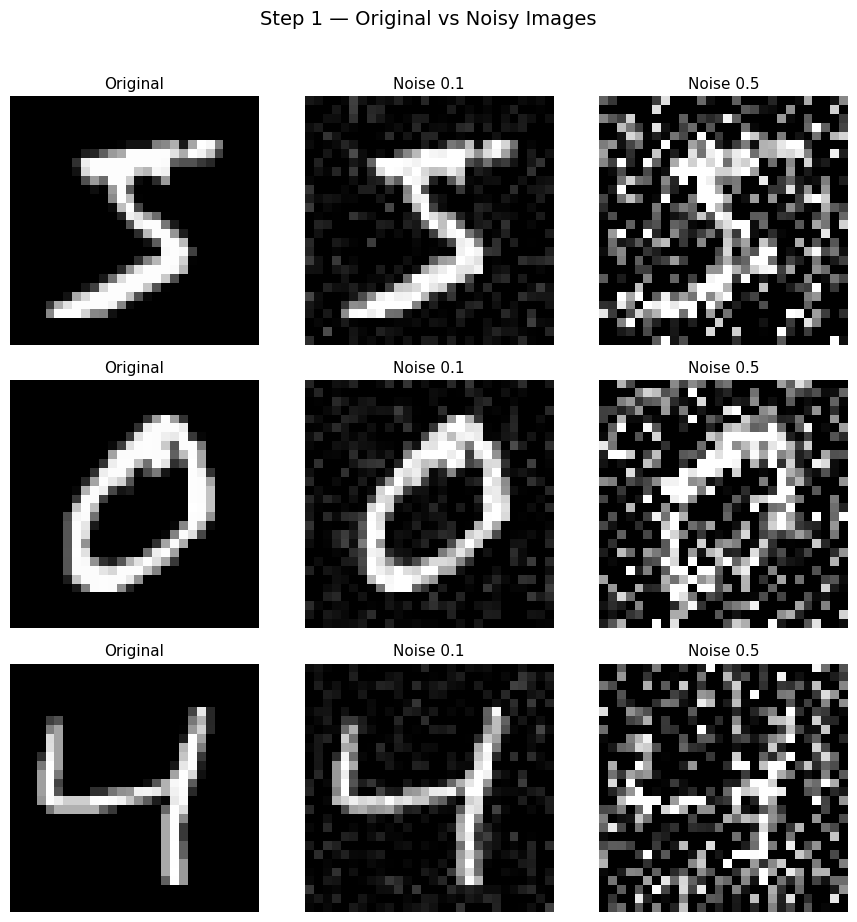

In [8]:
# ── 1.3  Visualise — Original vs Low Noise vs High Noise ─────────────────────
n = 3  # number of sample images to display
plt.figure(figsize=(9, 9))

for i in range(n):
    # Original
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original", fontsize=11)
    plt.axis('off')

    # Low noise (factor = 0.1)
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1", fontsize=11)
    plt.axis('off')

    # High noise (factor = 0.5)
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5", fontsize=11)
    plt.axis('off')

plt.suptitle("Step 1 — Original vs Noisy Images", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# NOTE: noise_factor controls how much noise is added.
# Higher value → more corruption; lower value → subtle noise.

In [9]:
# ── 2.1  Encoder ─────────────────────────────────────────────────────────────
def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.

    Parameters:
        input_shape (tuple): Shape of input image. Default (28,28,1) for MNIST.

    Returns:
        input_img (Keras Input) : Input layer.
        encoded   (Keras Tensor): Latent representation after conv + pooling.
    """
    input_img = Input(shape=input_shape, name="input")

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)  # (28,28,32)
    x = MaxPooling2D((2, 2), padding='same')(x)                           # (14,14,32)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)          # (14,14,64)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)     # (7, 7, 64)

    return input_img, encoded

In [10]:
# ── 2.2  Decoder ─────────────────────────────────────────────────────────────
def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.

    Parameters:
        encoded_input (Keras Tensor): Output from encoder (latent vector).

    Returns:
        decoded (Keras Tensor): Reconstructed output (same shape as input).
    """
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)  # (7, 7,64)
    x = UpSampling2D((2, 2))(x)                                               # (14,14,64)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)              # (14,14,32)
    x = UpSampling2D((2, 2))(x)                                               # (28,28,32)
    # Sigmoid → output pixel values in [0,1]; single channel to match grayscale input
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)  # (28,28,1)

    return decoded

In [11]:
# ── 2.3  Full Autoencoder ─────────────────────────────────────────────────────
def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder.

    Returns:
        autoencoder (Keras Model): Compiled autoencoder model ready for training.
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    # Binary cross-entropy suitable for normalised pixel values in [0,1]
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

# ── 2.4  Compile and inspect ──────────────────────────────────────────────────
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ── 3.1  Train ───────────────────────────────────────────────────────────────
history = autoencoder.fit(
    x_train_noisy_high, x_train,        # noisy → clean
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.1519 - val_loss: 0.1123
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1090 - val_loss: 0.1051
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1040 - val_loss: 0.1016
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1015 - val_loss: 0.0998
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0998 - val_loss: 0.0988
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0987 - val_loss: 0.0977
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0978 - val_loss: 0.0969
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0971 - val_loss: 0.0964
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0965 - val_loss: 0.0961
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0960 - val_loss: 0.0955


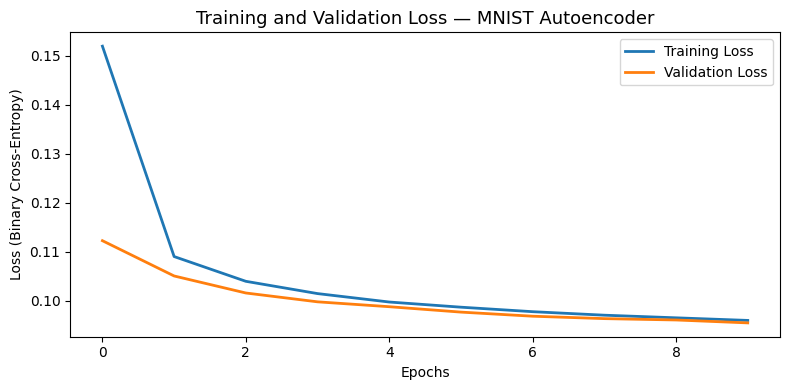

In [13]:
# ── 3.2  Plot Training & Validation Loss ─────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Training Loss',   linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss — MNIST Autoencoder', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.legend()
plt.tight_layout()
plt.show()

---
### Step 4: Evaluate the Autoencoder

In [14]:
# ── 4.1  Predict denoised images ─────────────────────────────────────────────
denoised_images = autoencoder.predict(x_test_noisy_high)
print(f"Denoised output shape: {denoised_images.shape}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Denoised output shape: (10000, 28, 28, 1)


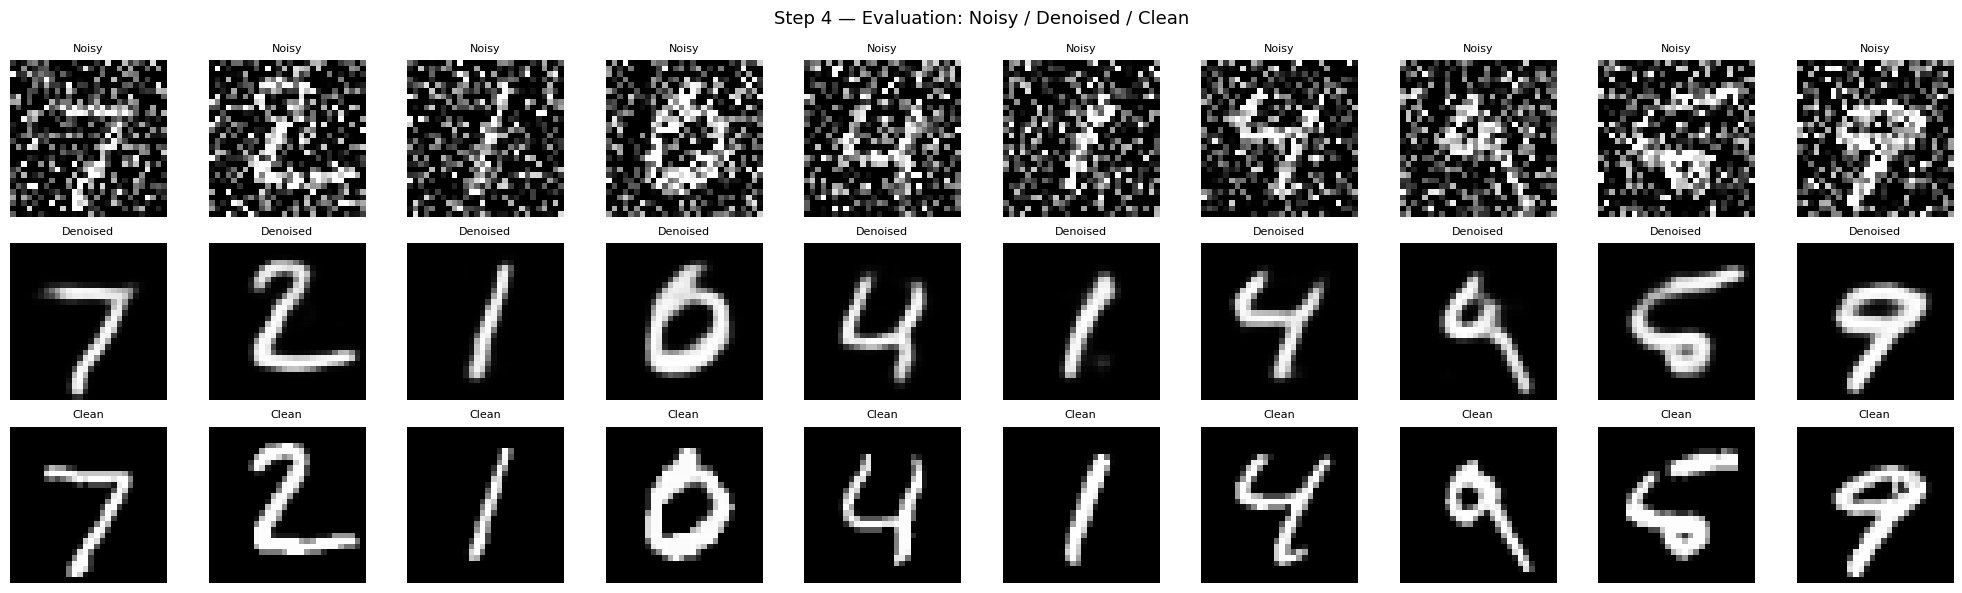

In [15]:
# ── 4.2  Visualise: Noisy | Denoised | Clean ──────────────────────────────────
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    """Display n image triplets: Noisy → Denoised → Clean."""
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Row 1 — Noisy
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy", fontsize=8)
        plt.axis('off')

        # Row 2 — Denoised (model output)
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised", fontsize=8)
        plt.axis('off')

        # Row 3 — Ground truth
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean", fontsize=8)
        plt.axis('off')

    plt.suptitle("Step 4 — Evaluation: Noisy / Denoised / Clean", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

### Exercise Step 1: Dataset Preparation and Preprocessing

In [26]:
import zipfile
import numpy as np
from PIL import Image
import io
from sklearn.model_selection import train_test_split
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/Copy of devnagari digit.zip"
IMG_SIZE = 32

def load_devnagari_from_zip(zip_path, img_size=32):
    images, labels = [], []

    with zipfile.ZipFile(zip_path, 'r') as z:
        file_list = z.namelist()

        # Find all digit folders ANYWHERE in zip
        digit_paths = sorted(set([
            "/".join(f.split('/')[:-1])   # get folder path
            for f in file_list
            if "digit_" in f and f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]))

        if not digit_paths:
            raise ValueError("❌ No digit folders found — check ZIP structure")

        print("✅ Found digit folders:", digit_paths[:10])  # debug preview

        # Map folder → label
        folder_to_label = {folder: idx for idx, folder in enumerate(digit_paths)}

        for file in file_list:
            if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            # Find which digit folder this file belongs to
            for folder in digit_paths:
                if file.startswith(folder):
                    try:
                        img_data = z.read(file)
                        img = Image.open(io.BytesIO(img_data)).convert('L')
                        img = img.resize((img_size, img_size), Image.LANCZOS)

                        images.append(np.array(img, dtype='float32'))
                        labels.append(folder_to_label[folder])

                    except:
                        print(f"Skipping: {file}")
                    break

    images = np.array(images, dtype='float32') / 255.0
    images = np.expand_dims(images, axis=-1)
    labels = np.array(labels)

    return images, labels


# ── Run ────────────────────────────────────────────────────────────────────
devnagari_images, devnagari_labels = load_devnagari_from_zip(ZIP_PATH, IMG_SIZE)

print(f"\n✅ Loaded {len(devnagari_images)} images")
print(f"Shape: {devnagari_images.shape}")
print(f"Labels: {len(np.unique(devnagari_labels))} classes")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found digit folders: ['DevanagariHandwrittenDigitDataset/Test/digit_0', 'DevanagariHandwrittenDigitDataset/Test/digit_1', 'DevanagariHandwrittenDigitDataset/Test/digit_2', 'DevanagariHandwrittenDigitDataset/Test/digit_3', 'DevanagariHandwrittenDigitDataset/Test/digit_4', 'DevanagariHandwrittenDigitDataset/Test/digit_5', 'DevanagariHandwrittenDigitDataset/Test/digit_6', 'DevanagariHandwrittenDigitDataset/Test/digit_7', 'DevanagariHandwrittenDigitDataset/Test/digit_8', 'DevanagariHandwrittenDigitDataset/Test/digit_9']

✅ Loaded 20000 images
Shape: (20000, 32, 32, 1)
Labels: 20 classes


In [27]:
# ── Exercise 1.2  Train / Validation Split ────────────────────────────────────
x_dev_train, x_dev_val = train_test_split(
    devnagari_images,
    test_size=0.15,
    random_state=42,
    stratify=devnagari_labels
)

print(f"Train: {x_dev_train.shape}  |  Validation: {x_dev_val.shape}")

Train: (17000, 32, 32, 1)  |  Validation: (3000, 32, 32, 1)


In [28]:
# ── Exercise 1.3  Add Gaussian Noise ─────────────────────────────────────────
NOISE_FACTOR = 0.4   # experiment: try 0.2, 0.3, 0.5

x_dev_train_noisy = add_gaussian_noise(x_dev_train, NOISE_FACTOR)
x_dev_val_noisy   = add_gaussian_noise(x_dev_val,   NOISE_FACTOR)

print(f"Noise factor applied: {NOISE_FACTOR}")

Noise factor applied: 0.4


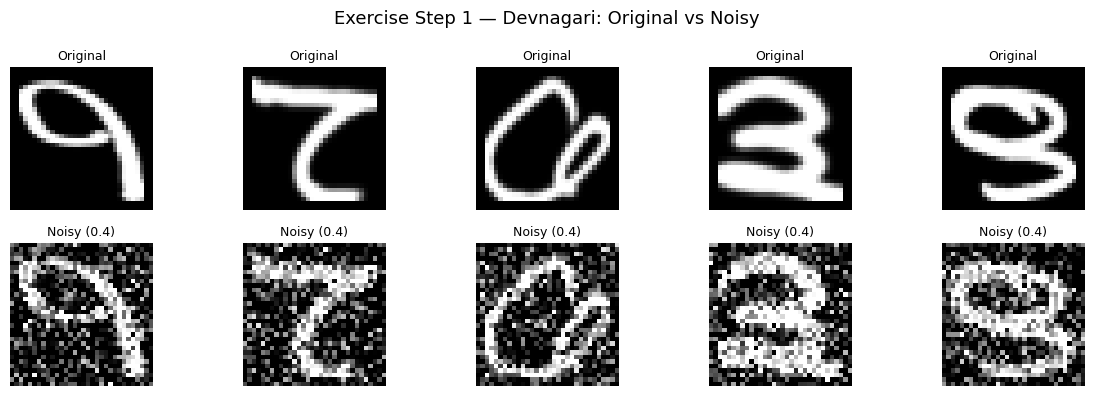

In [29]:
# ── Exercise 1.4  Visualise samples ──────────────────────────────────────────
n_vis = 5
plt.figure(figsize=(12, 4))
for i in range(n_vis):
    # Original
    plt.subplot(2, n_vis, i + 1)
    plt.imshow(x_dev_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Original", fontsize=9)
    plt.axis('off')

    # Noisy
    plt.subplot(2, n_vis, i + 1 + n_vis)
    plt.imshow(x_dev_train_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title(f"Noisy ({NOISE_FACTOR})", fontsize=9)
    plt.axis('off')

plt.suptitle("Exercise Step 1 — Devnagari: Original vs Noisy", fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
# ── Exercise 2.1  Deep Encoder (3 conv blocks = 6 trainable layers) ───────────
def build_deep_encoder(input_shape=(32, 32, 1)):
    """
    Deep encoder: 3 convolutional blocks with Batch Normalisation and Max Pooling.

    Spatial flow for 32×32 input:
        Input   → (32,32,1)
        Block 1 → Conv(32)  + BN + MaxPool → (16,16,32)
        Block 2 → Conv(64)  + BN + MaxPool → (8, 8, 64)
        Block 3 → Conv(128) + BN + MaxPool → (4, 4,128)  [latent space]
    """
    inputs = Input(shape=input_shape, name="dev_input")

    # ── Block 1 ──────────────────────────────────────────────────────────────
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(inputs)
    x = BatchNormalization(name='enc_bn1')(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)     # 16×16

    # ── Block 2 ──────────────────────────────────────────────────────────────
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
    x = BatchNormalization(name='enc_bn2')(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)     # 8×8

    # ── Block 3 ──────────────────────────────────────────────────────────────
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='enc_conv3')(x)
    x = BatchNormalization(name='enc_bn3')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name='dev_encoded')(x)  # 4×4

    return inputs, encoded

In [31]:
# ── Exercise 2.2  Deep Decoder ────────────────────────────────────────────────
def build_deep_decoder(encoded_input):
    """
    Deep decoder: mirrors the encoder using UpSampling + Conv layers.

    Spatial flow:
        Latent  → (4, 4,128)
        Block 1 → Conv(128) + BN + UpSample → (8, 8,128)
        Block 2 → Conv(64)  + BN + UpSample → (16,16, 64)
        Block 3 → Conv(32)  + BN + UpSample → (32,32, 32)
        Output  → Conv(1, sigmoid)           → (32,32,  1)
    """
    # ── Block 1 ──────────────────────────────────────────────────────────────
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='dec_conv1')(encoded_input)
    x = BatchNormalization(name='dec_bn1')(x)
    x = UpSampling2D((2, 2), name='dec_up1')(x)      # 8×8

    # ── Block 2 ──────────────────────────────────────────────────────────────
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='dec_conv2')(x)
    x = BatchNormalization(name='dec_bn2')(x)
    x = UpSampling2D((2, 2), name='dec_up2')(x)      # 16×16

    # ── Block 3 ──────────────────────────────────────────────────────────────
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='dec_conv3')(x)
    x = BatchNormalization(name='dec_bn3')(x)
    x = UpSampling2D((2, 2), name='dec_up3')(x)      # 32×32

    # ── Output layer — sigmoid keeps pixels in [0,1] ──────────────────────────
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='dev_decoded')(x)

    return decoded

In [33]:
# ── Exercise 2.3  Assemble & Compile ──────────────────────────────────────────
from tensorflow.keras.layers import BatchNormalization, Conv2D, MaxPooling2D
def build_deep_autoencoder(input_shape=(32, 32, 1)):
    """
    Builds and compiles the full deep convolutional autoencoder for Devnagari.

    Returns:
        autoencoder (Keras Model): Compiled model.
    """
    inputs, encoded_out = build_deep_encoder(input_shape)
    decoded_out = build_deep_decoder(encoded_out)
    autoencoder = Model(inputs=inputs, outputs=decoded_out, name="deep_denoising_autoencoder")
    autoencoder.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy'
    )
    return autoencoder


dev_autoencoder = build_deep_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, 1))
dev_autoencoder.summary()

Model: "deep_denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dev_input (InputLayer)          │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn1 (BatchNormalization)    │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn2 (BatchNormalization)    │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn3 (BatchNormalization)    │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dev_encoded (MaxPooling2D)      │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn1 (BatchNormalization)    │ (None, 4, 4, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn2 (BatchNormalization)    │ (None, 8, 8, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn3 (BatchNormalization)    │ (None, 16, 16, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up3 (UpSampling2D)          │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dev_decoded (Conv2D)            │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 334,593 (1.28 MB)

 Trainable params: 333,697 (1.27 MB)

 Non-trainable params: 896 (3.50 KB)

---
### Exercise Step 3: Train the Deep Denoising Autoencoder

In [34]:
# ── Exercise 3.1  Define callbacks ────────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    # Stop training early if val_loss stops improving
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    # Reduce learning rate if val_loss plateaus
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

In [35]:
# ── Exercise 3.2  Train ───────────────────────────────────────────────────────
dev_history = dev_autoencoder.fit(
    x_dev_train_noisy, x_dev_train,      # noisy → clean
    epochs=30,
    batch_size=64,
    shuffle=True,
    validation_data=(x_dev_val_noisy, x_dev_val),
    callbacks=callbacks
)

print("\nTraining complete.")

Epoch 1/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - loss: 0.2287 - val_loss: 0.7385 - learning_rate: 0.0010
Epoch 2/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1480 - val_loss: 0.1502 - learning_rate: 0.0010
Epoch 3/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1412 - val_loss: 0.1398 - learning_rate: 0.0010
Epoch 4/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1382 - val_loss: 0.1435 - learning_rate: 0.0010
Epoch 5/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.1357 - val_loss: 0.1368 - learning_rate: 0.0010
Epoch 6/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1342 - val_loss: 0.1404 - learning_rate: 0.0010
Epoch 7/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1330 - val_loss: 0.1365 - learning_rate: 0.0010
Epoch 8/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1320 - val_loss: 0.1351 - learning_rate: 0.0010
Epoch 9/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1312 - val_loss: 0.1335 - learning_rate: 0.0010
Epoch 1

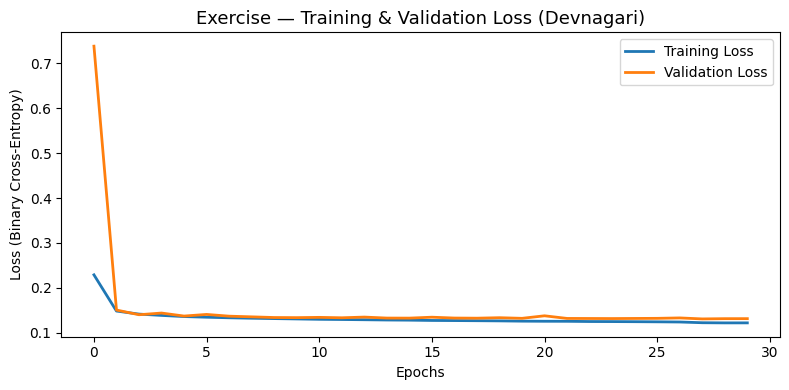

In [36]:
# ── Exercise 3.3  Plot Loss Curves ────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(dev_history.history['loss'],     label='Training Loss',   linewidth=2)
plt.plot(dev_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Exercise — Training & Validation Loss (Devnagari)', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.legend()
plt.tight_layout()
plt.show()

---
### Exercise Step 4: Evaluate and Visualise Results

In [37]:
# ── Exercise 4.1  Generate denoised predictions ───────────────────────────────
dev_denoised = dev_autoencoder.predict(x_dev_val_noisy)
print(f"Denoised output shape: {dev_denoised.shape}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
Denoised output shape: (3000, 32, 32, 1)


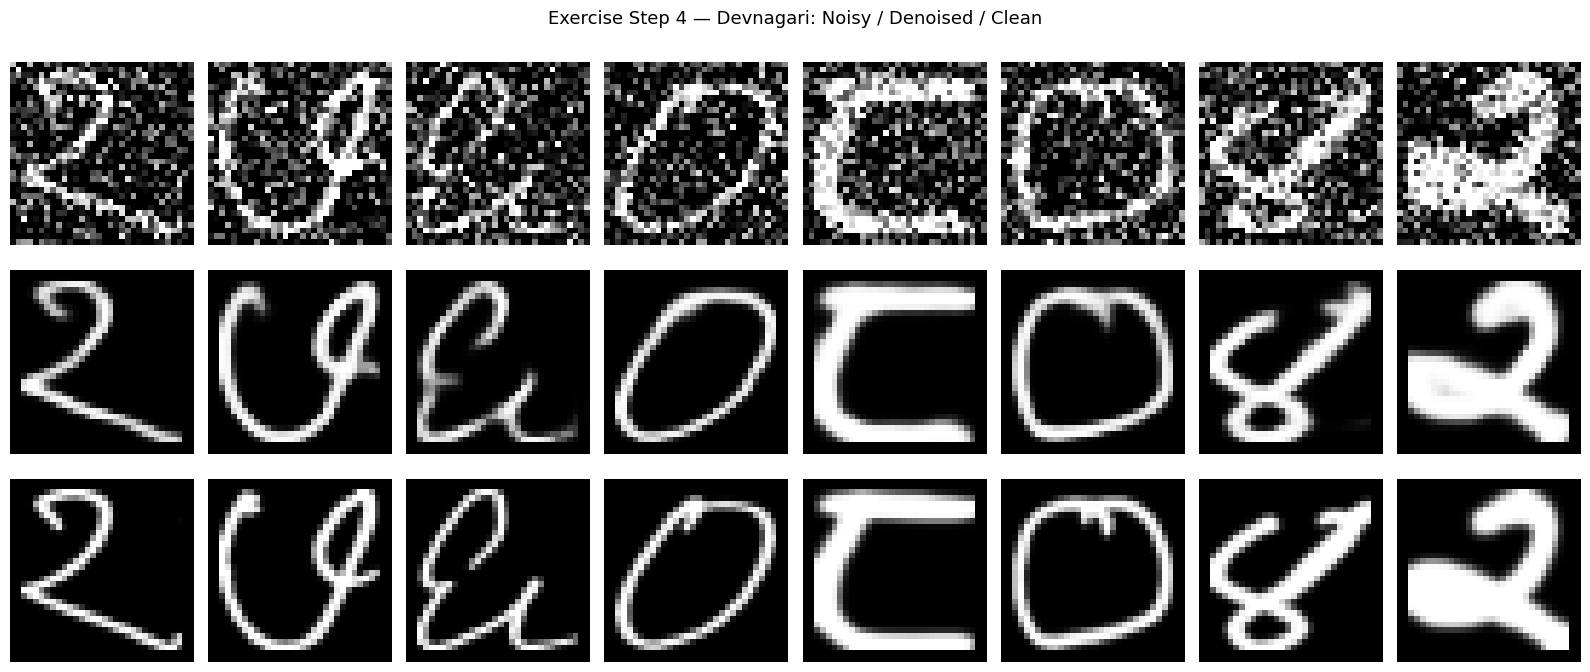

In [38]:
# ── Exercise 4.2  Visualise Noisy | Denoised | Clean ──────────────────────────
def plot_devnagari_results(noisy, denoised, clean, img_size=32, n=8):
    """Display n triplets: Noisy / Denoised / Clean for Devnagari images."""
    plt.figure(figsize=(n * 2, 7))

    row_labels = ["Noisy", "Denoised", "Clean"]
    rows = [noisy, denoised, clean]

    for row_idx, (row_data, row_label) in enumerate(zip(rows, row_labels)):
        for col_idx in range(n):
            plt.subplot(3, n, row_idx * n + col_idx + 1)
            plt.imshow(row_data[col_idx].reshape(img_size, img_size), cmap='gray')
            if col_idx == 0:
                plt.ylabel(row_label, fontsize=11, fontweight='bold')
            plt.axis('off')

    plt.suptitle("Exercise Step 4 — Devnagari: Noisy / Denoised / Clean", fontsize=13)
    plt.tight_layout()
    plt.show()


plot_devnagari_results(x_dev_val_noisy, dev_denoised, x_dev_val, img_size=IMG_SIZE, n=8)

In [39]:
# ── Exercise 4.3  Quantitative Evaluation — MSE & SSIM ───────────────────────
from skimage.metrics import structural_similarity as ssim

def evaluate_reconstruction(clean, denoised, img_size=32):
    """Compute mean MSE and SSIM between clean and denoised image sets."""
    mse_scores, ssim_scores = [], []
    for orig, pred in zip(clean, denoised):
        orig_2d = orig.reshape(img_size, img_size)
        pred_2d = pred.reshape(img_size, img_size)
        mse_scores.append(np.mean((orig_2d - pred_2d) ** 2))
        ssim_scores.append(ssim(orig_2d, pred_2d, data_range=1.0))
    return np.mean(mse_scores), np.mean(ssim_scores)

mse, ssim_score = evaluate_reconstruction(x_dev_val, dev_denoised, IMG_SIZE)
print(f"Mean Squared Error (MSE) : {mse:.6f}")
print(f"Mean SSIM                : {ssim_score:.4f}  (1.0 = perfect reconstruction)")

Mean Squared Error (MSE) : 0.008027
Mean SSIM                : 0.9297  (1.0 = perfect reconstruction)


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step

Experiment noise=0.2
  Best Val Loss : 0.118178
  MSE           : 0.004240
  SSIM          : 0.9617


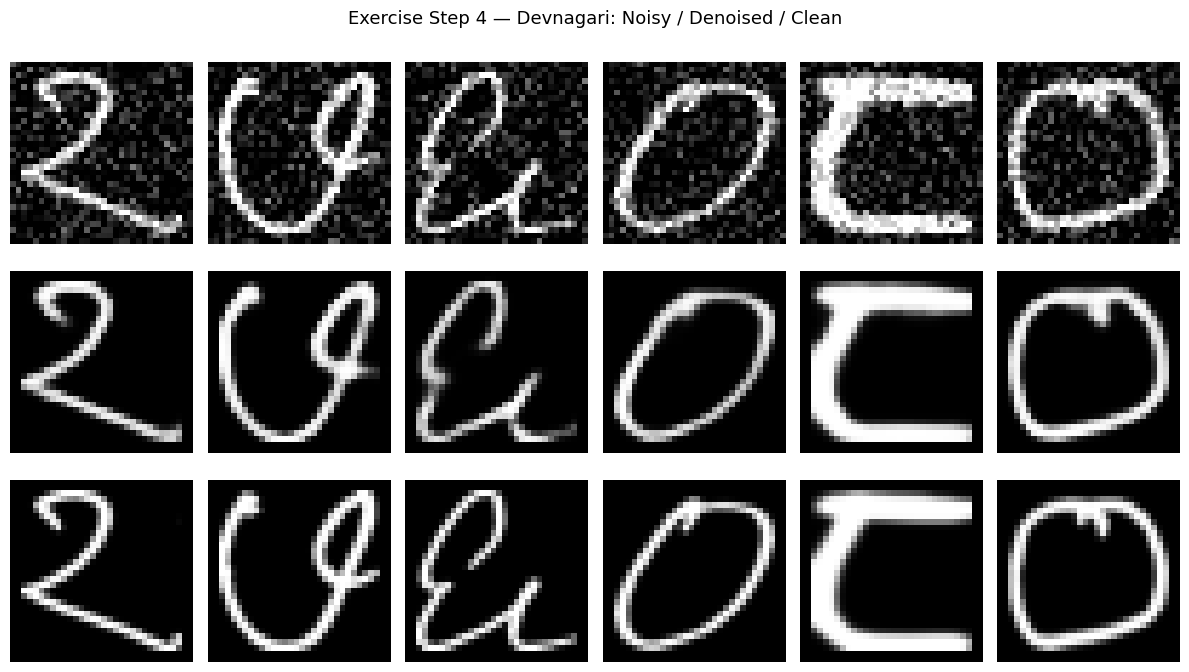

In [40]:
# ── Exercise 5 — Experiment Runner ───────────────────────────────────────────
# Change EXPERIMENT_NOISE below and re-run this cell to try different noise levels.

EXPERIMENT_NOISE = 0.2    # ← change to 0.2 / 0.3 / 0.4 / 0.6

x_exp_train_noisy = add_gaussian_noise(x_dev_train, EXPERIMENT_NOISE)
x_exp_val_noisy   = add_gaussian_noise(x_dev_val,   EXPERIMENT_NOISE)

exp_model = build_deep_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, 1))
exp_hist  = exp_model.fit(
    x_exp_train_noisy, x_dev_train,
    epochs=20,
    batch_size=64,
    shuffle=True,
    validation_data=(x_exp_val_noisy, x_dev_val),
    verbose=0,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)]
)

exp_denoised = exp_model.predict(x_exp_val_noisy)
exp_mse, exp_ssim = evaluate_reconstruction(x_dev_val, exp_denoised, IMG_SIZE)
final_val_loss = min(exp_hist.history['val_loss'])

print(f"\nExperiment noise={EXPERIMENT_NOISE}")
print(f"  Best Val Loss : {final_val_loss:.6f}")
print(f"  MSE           : {exp_mse:.6f}")
print(f"  SSIM          : {exp_ssim:.4f}")

plot_devnagari_results(x_exp_val_noisy, exp_denoised, x_dev_val, img_size=IMG_SIZE, n=6)